# Test how well POWHEG's reweighting is performing

In [1]:
import sys
import json
import argparse
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from pathlib import Path
from datetime import datetime
from typing import Any, Dict, List
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colorbar import Colorbar
from dataclasses import dataclass

# Get main path of the repository and add it to the path:
try:
    # For scripts
    repo_path = Path(__file__).parent.parent.parent.resolve()
except NameError:
    # For Jupyter notebooks - add the known project root
    repo_path = Path.cwd().parent.parent.resolve()

# Add parent directory to path
sys.path.insert(0, str(repo_path))

from ml_events_utils import stylesheet_default
from ml_events_utils import color_gio as color_dict
# from ml_events_utils import color_deep as color_dict

from plot_utils import *
from data_utils import HistogramData, read_histogram

# Plot directory:
plot_dir = repo_path / "final_results" / "plots" / "reweighting_test"
plot_dir.mkdir(parents=True, exist_ok=True)


# Set datapaths:
data_dir = repo_path / "final_results/reweighting_test"

reweighting_dir = data_dir / "reweighting"
direct_sim_dir  = data_dir / "direct_simulation"

plt.style.use(stylesheet_default)

HistogramData.colors = {
    "ll": color_dict["red"],
    "lt": color_dict["yellow"],
    "tl": color_dict["green"],
    "lt+tl": color_dict["green"],
    "tt": color_dict["blue"],
    "uu": color_dict["gray"],
}
HistogramData.colors["tl+lt"] = HistogramData.colors["lt+tl"]

labels_pol = {
    "ll": r"$Z_{\mathrm{L}} \, Z_{\mathrm{L}}$",
    "lt": r"$Z_{\mathrm{L}} \, Z_{\mathrm{T}}$",
    "tl": r"$Z_{\mathrm{T}} \, Z_{\mathrm{L}}$",
    "lt+tl": r"$Z_{\mathrm{L}} \, Z_{\mathrm{T}} + Z_{\mathrm{T}} \, Z_{\mathrm{L}}$",
    "tt": r"$Z_{\mathrm{T}} \, Z_{\mathrm{T}}$",
    "uu": r"$Z_{\mathrm{U}} \, Z_{\mathrm{U}}$",
}
labels_pol["tl+lt"] = labels_pol["lt+tl"]

observables_latex = {
    "totxsec": r"$\sigma_{\mathrm{tot}}$",
    "ptep":    r"$p_{\mathrm{T}, \, e^{+}}$",
    "yep":     r"$y_{e^{+}}$",
    "cthep":   r"$\cos(\theta^{*}_{e^{+}})$",
    "mepem":   r"$m_{e^{+} e^{-}}$",
    "dphiee":  r"$\Delta \phi_{e^{+} e^{-}}$",  # Azimuthal angle difference between e+ e-, coming from one of the Z bosons.
    "ptee":    r"$p_{\mathrm{T}, \, e^{+} e^{-}}$",
    "pt4l":    r"$p_{\mathrm{T}, \, 4l}$",
}


## Load data

In [2]:
# polarisations = ["ll", "lt", "tl", "tt", "uu"]
polarisations = ["tt", "ll", "lt", "tl"]

orders = ["lo","nloqcd", "nlops"]

# hist-file: adjusted name
observable_map_dsim = {
    "totxsec": "totxsec",
    "ptep":    "ptep",
    "yep":     "yep",
    "cthep":   "cthep",
    "mee":     "mepem",
    "dphiee":  "dphiee",
    "ptee":    "ptee",
    "pt4l":    "pt4l",
}

observable_map_rwgt = {
    "totxsec": "totxsec",
    "ptep":    "ptep",
    "yep":     "yep",
    "cthep":   "cthep",
    "mee":     "mepem",
    "dphiee":  "dphiee",
    "ptee":    "ptee",
    "pt4l":    "pt4l",
}

dsim_data = {}  # Direct simulation data
rwgt_data = {}  # Reweighting data
for order in orders:
    dsim_data[order] = {}
    rwgt_data[order] = {}
    for pol in polarisations:
        # Direct simulation:
        path_dsim = direct_sim_dir / f"pwg_{order}_{pol}.dat"
        dsim_data[order][pol] = read_histogram(path_dsim, 1.0, observable_map=observable_map_dsim, name=f"dsim_{order}_{pol}", order=order, style={"color": HistogramData.colors[pol], "linestyle": "--"})

        # Reweighting:
        path_rwgt = reweighting_dir / f"pwg_{order}_{pol}.top"
        rwgt_data[order][pol] = read_histogram(path_rwgt, 1e3, observable_map=observable_map_rwgt, name=f"rwgt_{order}_{pol}", order=order, style={"color": HistogramData.colors[pol]})

    dsim_data[order]["lt+tl"] = {}
    rwgt_data[order]["lt+tl"] = {}
    for observable in dsim_data[order][polarisations[0]].keys():
        dsim_data[order]["lt+tl"][observable] = dsim_data[order]["lt"][observable] + dsim_data[order]["tl"][observable]
        dsim_data[order]["lt+tl"][observable].style["color"] = HistogramData.colors["lt+tl"]
        rwgt_data[order]["lt+tl"][observable] = rwgt_data[order]["lt"][observable] + rwgt_data[order]["tl"][observable]
        rwgt_data[order]["lt+tl"][observable].style["color"] = HistogramData.colors["lt+tl"]

    dsim_data[order]["tl+lt"] = dsim_data[order]["lt+tl"]
    rwgt_data[order]["tl+lt"] = rwgt_data[order]["lt+tl"]


polarisations.append("lt+tl")

## Examine parton shower effects

In [3]:
def plot_observable_function(histograms: dict,
                             xrange: list,
                             title:str,
                             xlabel:str,
                             unit:str,
                             ylabel1:str,
                             yranges:list=[],
                             logs:list = [False, False],
                             legends:list=[{}, {}],
                             rcParams:dict={},
                             uncertainties:bool=False,
                             ):

    """
    histogram: dict = {
                        pol: [dsim_data["nlops"][pol], dsim_data["nloqcd"][pol]] for pol in polarisations
                      }

    Plots:
        Top:
    """
    # order_tex_lo    = r"$\mathrm{LO}$"
    order_tex_nlo   = r"$\mathrm{NLO}_{\mathrm{QCD}}$"
    order_tex_nlops = r"$\mathrm{NLO}_{\mathrm{QCD}} \times \mathrm{PS}_{\mathrm{QCD}}$"

    with plt.style.context(stylesheet_default):
        plot_polarisations = ["tt", "lt+tl", "ll"]
        n_plots = 1

        mpl.rcParams.update(rcParams)
        size = mpl.rcParams['figure.figsize']
        scale_factor = 1.0 + 0.5*(n_plots-1)
        height_ratios = [3,] + [1,]*(n_plots-1)
        fig, axs = plt.subplots(n_plots, 1, sharex=True, figsize=(size[0], scale_factor*size[1]), height_ratios=height_ratios)
        if n_plots == 1:
            axs = [axs,]
        ylabels = ["",] * n_plots


        if len(xrange) == 3:
            width_bins = xrange[2]

            for key, runs in histograms.items():
                histograms[key] = [runs[i].rebin(width_bins) for i in range(len(runs))]

        weights_sig = []
        styles = []
        labels = [labels_pol[pol] for pol in plot_polarisations]
        for _ in range(len(labels)):
            labels.append(None)  # Add None labels for the reweighting histograms, so that they don't appear in the legend


        for pol in plot_polarisations:
            histogram = histograms[pol][0]
            weights_sig.append((histogram.bins, histogram.values, histogram.errors))
            styles.append(histogram.style)
            styles[-1].update({"linestyle": "-"})

        for pol in plot_polarisations:
            histogram = histograms[pol][1]
            weights_sig.append((histogram.bins, histogram.values, histogram.errors))
            styles.append(histogram.style)
            styles[-1].update({"linestyle": "--"})

        iplot = 0
        plot_histograms(axs[iplot], weights_sig, labels=labels, styles=styles, uncertainties=uncertainties)
        ylabels[iplot] = ylabel1


        axs[0].text(
            0.02,
            0.98,
            f"dashed: {order_tex_nlo}" + "\n" + f"solid: {order_tex_nlops}",
            transform=axs[0].transAxes,
            va='top',
            ha='left',
        )

        axs[0].set_title(title)
        if unit:
            xlabel  += f" [{unit}]"

        axs[n_plots-1].set_xlabel(xlabel)

        for i, log, yrange, legend in zip(list(range(n_plots)), logs, yranges, legends):
            axs[i].set_ylabel(ylabels[i])
            if log:
                axs[i].set_yscale('log')
            if yrange:
                axs[i].set_ylim(yrange)

            if legend:
                add_legend(axs[i], **legend)
            else:
                add_legend(axs[i], legloc="lower left")

        move_offset_factor(axs[0], ylabels[0])

        return fig, axs

### Input

Plotting observable cthep.


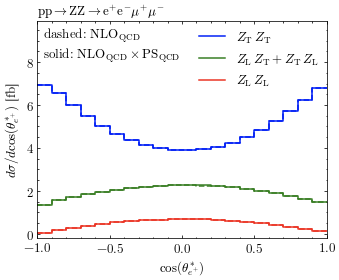

Plotting observable ptep.


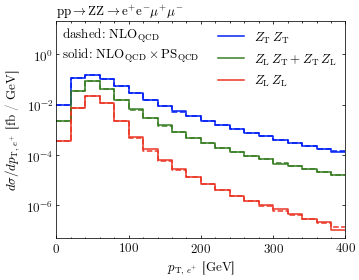

Plotting observable yep.


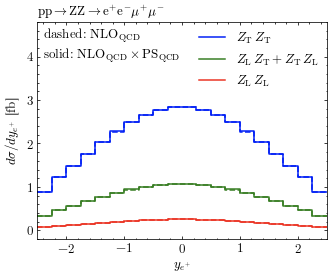

Plotting observable mepem.


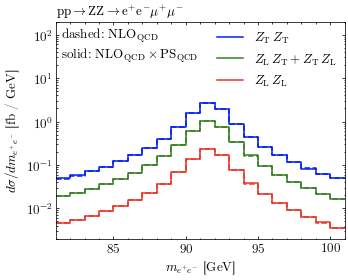

Plotting observable dphiee.


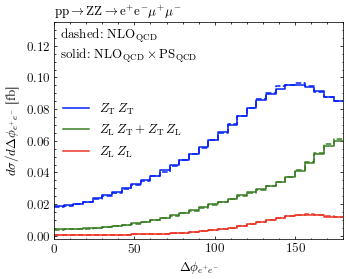

Plotting observable ptee.


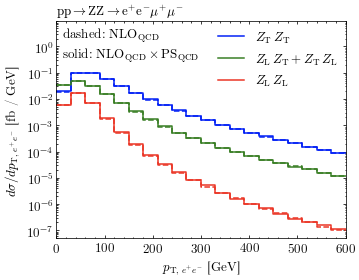

Plotting observable pt4l.


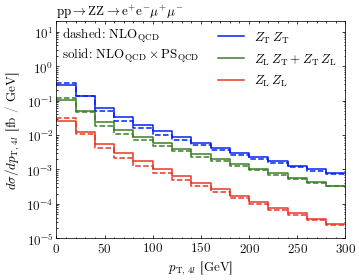

In [13]:
metadata = {'Title': "Examine parton shower effects on NLO QCD predictions for various observables",
            'Author': 'Jakob Linder',
            'CreationDate': datetime.today(),
            'ModDate': datetime.today(),
            'Creator': 'Python'}
fp_rcParams = {}
plt.close()

plot_observables = {
    # observables_key: [tex_xlabel, unit, xrange and bin width, [yrange1, ], [log1, log2, log3], [legend1, legend2, legend3]]  # default xrange
    "cthep"   : [observables_latex["cthep"],   r"",    [ -1.,  +1.,  0.1], [[-0.2, 9.9],     ], [False, ], [{"legloc": "upper right",}, ], ],  # [ -1.,  +1., 0.05]
    "ptep"    : [observables_latex["ptep"],    r"GeV", [  0., 400.,  20.], [[5e-8, 2e1],     ], [True,  ], [{"legloc": "upper right"},  ], ],  # [  0., 400.,  10.]
    "yep"     : [observables_latex["yep"],     r"",    [-2.5, +2.5,     ], [[-0.2, 4.8],     ], [False, ], [{"legloc": "upper right",}, ], ],  # [-2.5, +2.5, 0.05]
    "mepem"   : [observables_latex["mepem"],   r"GeV", [ 81., 101.,   1.], [[2e-3, 2e2],     ], [True,  ], [{"legloc": "upper right",}, ], ],  # [ 81., 101.,  0.5]
    "dphiee"  : [observables_latex["dphiee"],  r"",    [  0., 180.,   6.], [[-0.002, 0.135], ], [False, ], [{"legloc": "center left"},  ], ],  # [  0., 180.,   6.]
    "ptee"    : [observables_latex["ptee"],    r"GeV", [  0., 600.,  30.], [[5e-8, 9e0],     ], [True,  ], [{"legloc": "upper right"},  ], ],  # [  0., 600.,  15.]
    "pt4l"    : [observables_latex["pt4l"],    r"GeV", [  0., 300.,  20.], [[1e-5, 2e1],     ], [True,  ], [{"legloc": "upper right"},  ], ],  # [  0., 300.,   5.]
}


# Set rebinned bins explicitly as list in order to avoid rounding issues.
for key in plot_observables.keys():
    if len(plot_observables[key][2]) == 3:
        plot_observables[key][2][2] = np.arange(plot_observables[key][2][0], plot_observables[key][2][1] + plot_observables[key][2][2], plot_observables[key][2][2])

file = plot_dir / Path(f"observables_nloqcd_ps_comparison.pdf")
with PdfPages(filename=file, metadata=metadata) as pdf:
    for fp_observable, (fp_xlabel, fp_unit, fp_xrange, fp_yranges, fp_logs, fp_legends) in plot_observables.items():
        print(f"Plotting observable {fp_observable}.")

        histograms = {
            pol: [dsim_data["nlops"][pol][fp_observable], dsim_data["nloqcd"][pol][fp_observable]] for pol in polarisations
        }
        fp_title  = r"$\mathrm{p} \mathrm{p} \rightarrow \mathrm{ZZ} \rightarrow \mathrm{e}^{+} \mathrm{e}^{-} \mu^{+} \mu^{-}$"
        fp_ylabel1 = r"$d \sigma / d " + fp_xlabel[1:-1] + r"$ [fb]"
        if fp_unit:
            fp_ylabel1 = fp_ylabel1[:-1] + f" / {fp_unit}]"


        fig, axs = plot_observable_function(histograms,
                                            xrange=fp_xrange,
                                            title=fp_title,
                                            xlabel=fp_xlabel,
                                            unit=fp_unit,
                                            ylabel1=fp_ylabel1,
                                            yranges=fp_yranges,
                                            logs=fp_logs,
                                            legends=fp_legends,
                                            rcParams=fp_rcParams,
                                            uncertainties=False,
                                        )

        pdf.savefig(fig)
        plt.show()



## Plot comparison of direct simulation and reweighting

Plot the LL, LT$+$TL and TT polarisation distribution for the directly simulated events and for them being reweighted onto the specific polarisation.

The second plot is the pull of the distributions, i.e.
$$
\dfrac{\sigma_{\mathrm{rwgt}} - \sigma_{\mathrm{dsim}}}{\sqrt{\mathrm{err}^{2}_{\sigma_{\mathrm{rwgt}}} + \mathrm{err}^{2}_{\sigma_{\mathrm{dsim}}}} }
$$

The third panel contains the ratio, i.e.
$$
\dfrac{\sigma_{\mathrm{rwgt}}}{\sigma_{\mathrm{dsim}}}
$$

In [5]:
def plot_observable_ratio(histograms: dict,
                          xrange: list,
                          title:str,
                          xlabel:str,
                          unit:str,
                          ylabel1:str,
                          yranges:list=[],
                          logs:list = [False, False],
                          legends:list=[{}, {}],
                          rcParams:dict={},
                          uncertainties:bool=False,
                          order:str="lo",
                         ):

    """
    histogram: dict = {
                        pol: [dsim_data[order][pol], rwgt_data[order][pol]] for pol in polarisations
                      }

    Plots:
        Top:    Direct simulation and reweighting histograms.
        Ratio1: Pull w.r.t. direct simulation: (reweighting - direct simulation) / sqrt(errors^2).
        Ratio2: Ratio to direct simulation: reweighting / direct simulation.
    """
    with plt.style.context(stylesheet_default):
        plot_polarisations = ["tt", "lt+tl", "ll"]
        n_plots = 3

        mpl.rcParams.update(rcParams)
        size = mpl.rcParams['figure.figsize']
        scale_factor = 1.0 + 0.5*(n_plots-1)
        height_ratios = [3,] + [1,]*(n_plots-1)
        fig, axs = plt.subplots(n_plots, 1, sharex=True, figsize=(size[0], scale_factor*size[1]), height_ratios=height_ratios)
        ylabels = ["",] * n_plots



        if len(xrange) == 3:
            width_bins = xrange[2]

            for key, dsim_rwgt in histograms.items():
                histograms[key] = [dsim_rwgt[i].rebin(width_bins) for i in range(len(dsim_rwgt))]

        weights_sig = []
        styles = []
        labels = [labels_pol[pol] for pol in plot_polarisations]
        for _ in range(len(labels)):
            labels.append(None)  # Add None labels for the reweighting histograms, so that they don't appear in the legend


        for i in range(2-1, -1, -1):  # Loop over both direct simulation and reweighting histograms
            for pol in plot_polarisations:
                dsim_rwgt = histograms[pol]
                histogram = dsim_rwgt[i]
                weights_sig.append((histogram.bins, histogram.values, histogram.errors))
                styles.append(histogram.style)

        iplot = 0
        plot_histograms(axs[iplot], weights_sig, labels=labels, styles=styles, uncertainties=uncertainties)
        ylabels[iplot] = ylabel1

        #  Pull plot
        weights_sig = []
        styles      = []
        for i, pol in enumerate(plot_polarisations):
            if order != "lo" and pol == "lt+tl":
                # Skip the lt+tl combination for NLO and NLOPS, since it is just ot far of in the pull plot.
                continue
            dsim_rwgt = histograms[pol]

            dsim_hist = dsim_rwgt[0]  # Direct simulation histogram
            rwgt_hist = dsim_rwgt[1]  # Reweighted histogram

            ratio_histogram = (rwgt_hist - dsim_hist) / np.sqrt(rwgt_hist.errors**2 + dsim_hist.errors**2)
            weights_sig.append((ratio_histogram.bins, ratio_histogram.values, ratio_histogram.errors))
            styles.append(ratio_histogram.style)

        iplot = 1
        axs[iplot].fill_between(ratio_histogram.bins, -3.0, 3.0, color=color_dict['gray'], alpha=0.3, zorder=-1)
        axs[iplot].axhline(0.0, color=color_dict['black'], linestyle='--', linewidth=1)
        plot_histograms(axs[iplot], weights_sig, labels=None, styles=styles, uncertainties=False)

        if not yranges[iplot]:
            yranges[iplot] = [-4.9, +7]

        ylabels[iplot] = f"pull w.r.t. direct simulation"
        axs[iplot].text(
            0.02,
            0.94,
            ylabels[iplot],
            transform=axs[iplot].transAxes,
            va='top',
            ha='left',
        )
        ylabels[iplot] = ""


        #  Ratio plot
        weights_sig = []
        styles      = []
        for i, pol in enumerate(plot_polarisations):
            dsim_rwgt = histograms[pol]

            dsim_hist = dsim_rwgt[0]  # Direct simulation histogram
            rwgt_hist = dsim_rwgt[1]  # Reweighted histogram

            ratio_histogram = rwgt_hist / dsim_hist
            weights_sig.append((ratio_histogram.bins, ratio_histogram.values, ratio_histogram.errors))
            styles.append(ratio_histogram.style)

        iplot = 2
        plot_histograms(axs[iplot], weights_sig, labels=None, styles=styles, uncertainties=uncertainties)
        axs[iplot].axhline(1.0, color=color_dict['black'], linestyle='--', linewidth=1)

        ylabels[iplot] = f"ratio to direct simulation"
        axs[iplot].text(
            0.02,
            0.94,
            ylabels[iplot],
            transform=axs[iplot].transAxes,
            va='top',
            ha='left',
        )
        ylabels[iplot] = ""


        axs[0].text(
            0.02,
            0.98,
            r"dashed: direct simulation" + "\n" + r"solid: reweighting",
            transform=axs[0].transAxes,
            va='top',
            ha='left',
        )

        axs[0].set_title(title)
        if unit:
            xlabel  += f" [{unit}]"

        axs[n_plots-1].set_xlabel(xlabel)

        for i, log, yrange, legend in zip(list(range(n_plots)), logs, yranges, legends):
            axs[i].set_ylabel(ylabels[i])
            if log:
                axs[i].set_yscale('log')
            if yrange:
                axs[i].set_ylim(yrange)

            if legend:
                add_legend(axs[i], **legend)
            else:
                add_legend(axs[i], legloc="lower left")

        move_offset_factor(axs[0], ylabels[0])

        return fig, axs

### Input

Plotting observable cthep @ lo.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


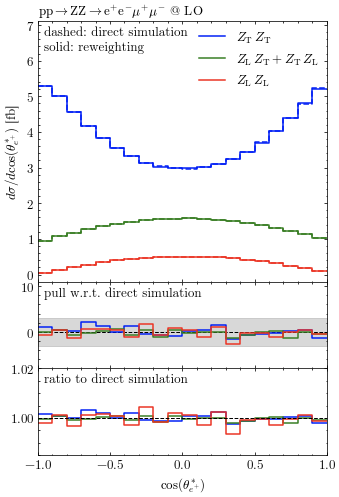

Plotting observable ptep @ lo.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


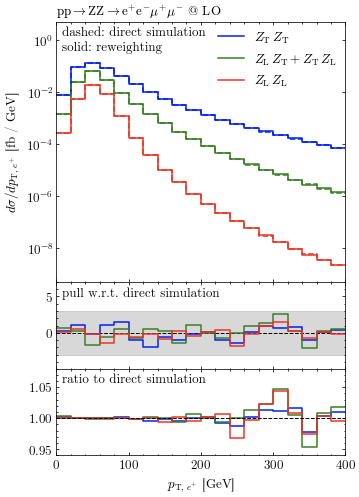

Plotting observable yep @ lo.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


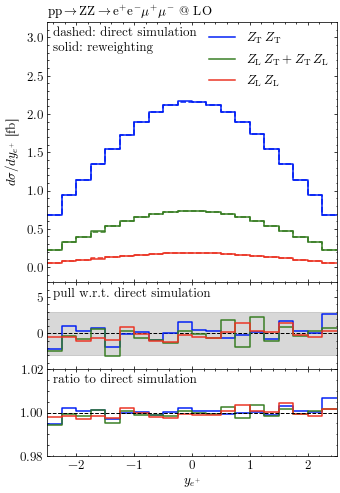

Plotting observable mepem @ lo.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


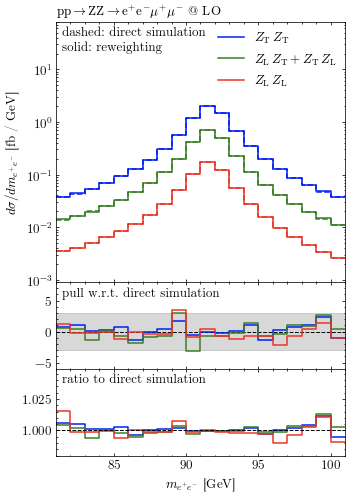

Plotting observable dphiee @ lo.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


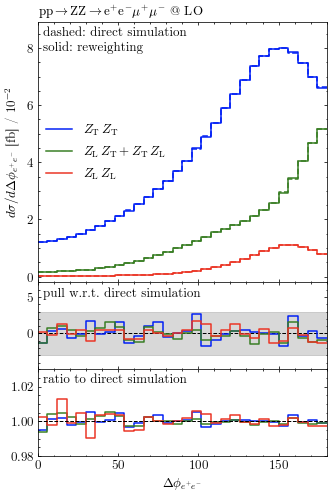

Plotting observable ptee @ lo.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


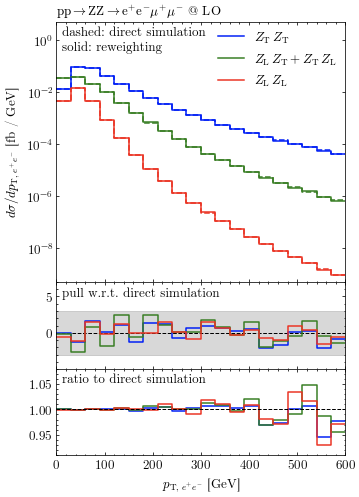

Plotting observable cthep @ nloqcd.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


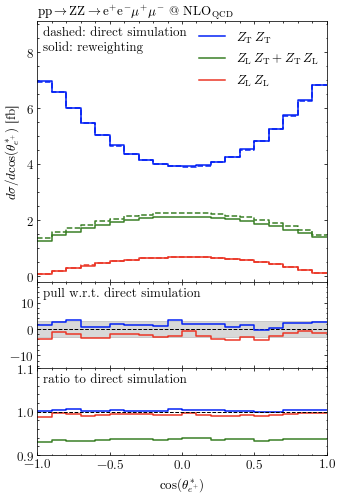

Plotting observable ptep @ nloqcd.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


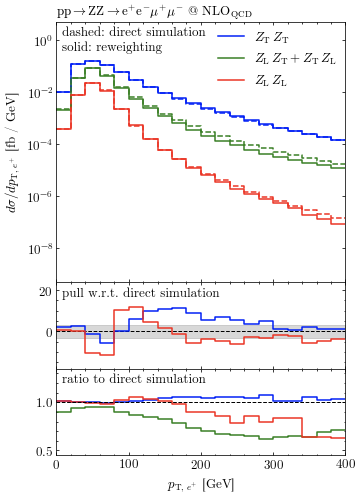

Plotting observable yep @ nloqcd.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


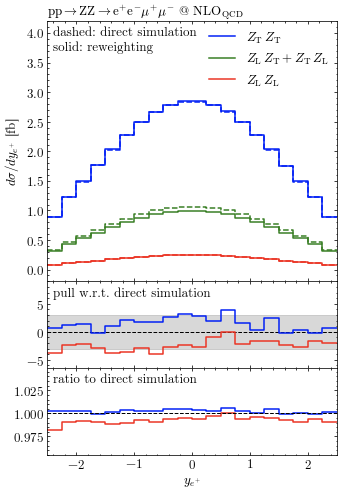

Plotting observable mepem @ nloqcd.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


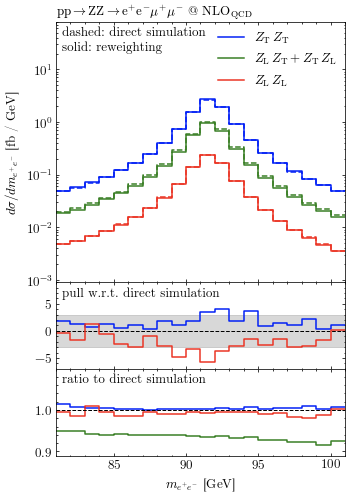

Plotting observable dphiee @ nloqcd.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


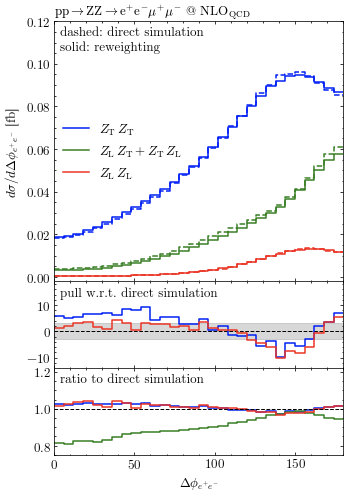

Plotting observable ptee @ nloqcd.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


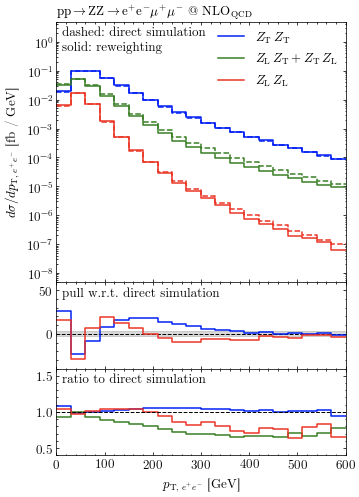

Plotting observable pt4l @ nloqcd.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


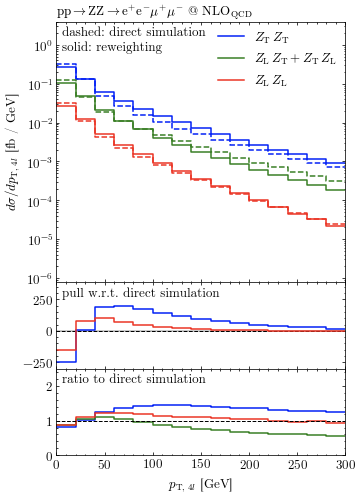

Plotting observable cthep @ nlops.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


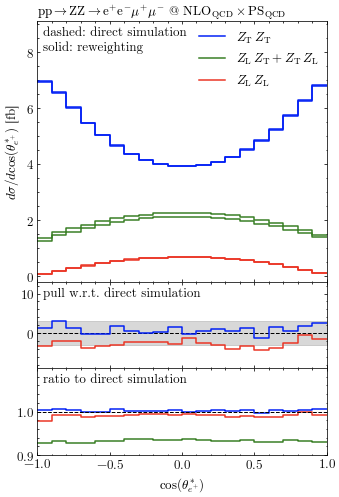

Plotting observable ptep @ nlops.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


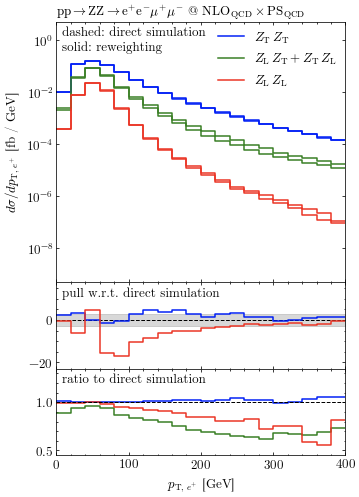

Plotting observable yep @ nlops.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


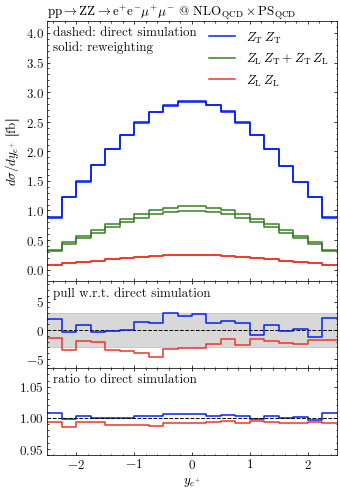

Plotting observable mepem @ nlops.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


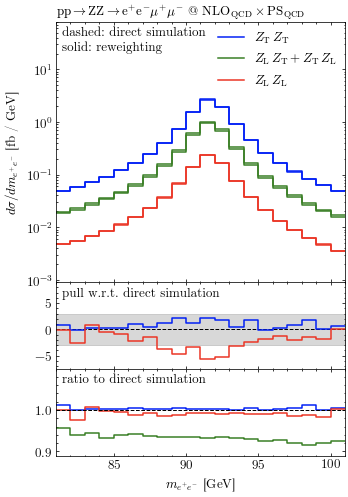

Plotting observable dphiee @ nlops.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


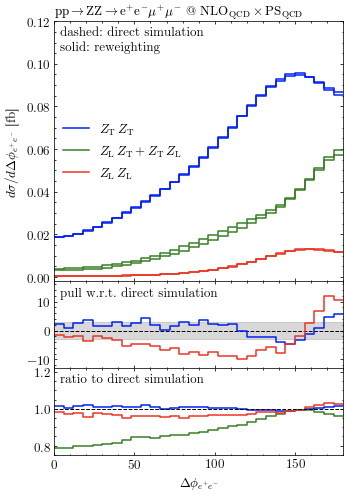

Plotting observable ptee @ nlops.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


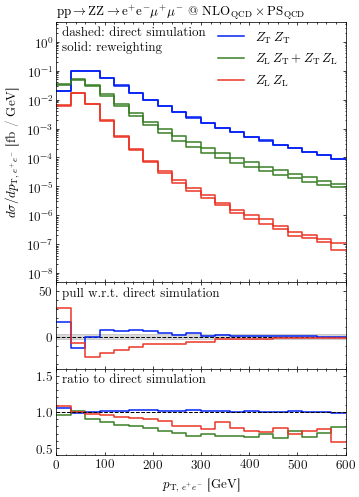

Plotting observable pt4l @ nlops.


/Users/linder/polarisation_tagging/final_results/plots/plot_utils.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


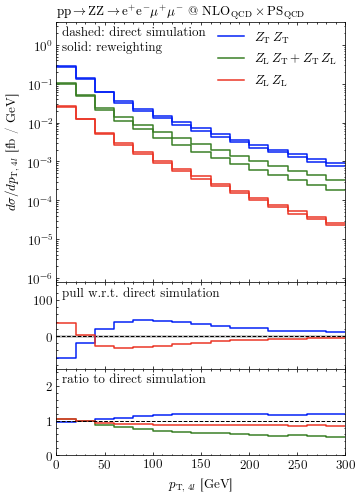

In [6]:
metadata = {'Title': "Reweighting test",
            'Author': 'Jakob Linder',
            'CreationDate': datetime.today(),
            'ModDate': datetime.today(),
            'Creator': 'Python'}

fp_rcParams = {}

# for order in ["nloqcd", "nlops", ]:
for order in orders:
    if order == "lo":
        plot_observables = {
            # FIXME: Why is having less bins in cthep making the pull plot look worse, while the ratio are looking better?
            # observables_key: [tex_xlabel, unit, xrange and bin width, [yrange1, yrange2, yrange3], [log1, log2, log3], [legend1, legend2, legend3]]  # default xrange
            "cthep"   : [observables_latex["cthep"],   r"",    [ -1.,  +1.,  0.1], [[-0.2, 7.1],       [-8, +11], [0.985, 1.02],], [False, False, False], [{"legloc": "upper right",}, {}, {}], ],  # [ -1.,  +1., 0.05]
            "ptep"    : [observables_latex["ptep"],    r"GeV", [  0., 400.,  20.], [[5e-10, 5e0],      [],        [0.94,  1.08],], [True,  False,  False], [{"legloc": "upper right"},    {}, {}], ],  # [  0., 400.,  10.]
            "yep"     : [observables_latex["yep"],     r"",    [-2.5, +2.5,     ], [[-0.2, 3.2],       [],        [0.98,  1.02],], [False, False, False], [{"legloc": "upper right",}, {}, {}], ],  # [-2.5, +2.5, 0.05]
            "mepem"   : [observables_latex["mepem"],   r"GeV", [ 81., 101.,   1.], [[9e-4, 8e1],       [-6, +8],  [0.98, 1.049],], [True,  False, False],  [{"legloc": "upper right",}, {}, {}], ],  # [ 81., 101.,  0.5]
            "dphiee"  : [observables_latex["dphiee"],  r"",    [  0., 180.,   6.], [[-0.2e-2, 8.9e-2], [],        [0.98,  1.03],], [False, False, False], [{"legloc": "center left"},    {}, {}], ],  # [  0., 180.,   6.]
            "ptee"    : [observables_latex["ptee"],    r"GeV", [  0., 600.,  30.], [[5e-10, 5e0],      [],        [0.91,  1.08],], [True,  False, False], [{"legloc": "upper right"},   {}, {}], ],  # [  0., 600.,  15.]
            # "pt4l"    : [observables_latex["pt4l"],    r"GeV", [  0., 300.,  20.], [[], [], [],], [True,  False, False], [{"legloc": "upper right"},   {}, {}], ],  # [  0., 300.,   5.]
        }
        order_tex = r"$\mathrm{LO}$"
    elif order == "nloqcd":
        plot_observables = {
            # observables_key: [tex_xlabel, unit, xrange and bin width, [yrange1, yrange2, yrange3], [log1, log2, log3], [legend1, legend2, legend3]]  # default xrange
            "cthep"   : [observables_latex["cthep"],   r"",    [ -1.,  +1.,  0.1], [[-0.2, 9.1],       [-15, +18],    [0.9,    1.10],], [False, False, False], [{"legloc": "upper right",}, {}, {}], ],  # [ -1.,  +1., 0.05]
            "ptep"    : [observables_latex["ptep"],    r"GeV", [  0., 400.,  20.], [[5e-10, 5e0],      [-18, +24],     [0.45,   1.35],], [True,  False,  False], [{"legloc": "upper right"},    {}, {}], ],  # [  0., 400.,  10.]
            "yep"     : [observables_latex["yep"],     r"",    [-2.5, +2.5,     ], [[-0.2, 4.2],       [-6.5, +9.0],   [0.955, 1.049],], [False, False, False], [{"legloc": "upper right",}, {}, {}], ],  # [-2.5, +2.5, 0.05]
            "mepem"   : [observables_latex["mepem"],   r"GeV", [ 81., 101.,   1.], [[9e-4, 8e1],       [-7.0, +9.0],  [0.89,  1.099],], [True,  False, False],  [{"legloc": "upper right",}, {}, {}], ],  # [ 81., 101.,  0.5]
            "dphiee"  : [observables_latex["dphiee"],  r"",    [  0., 180.,   6.], [[-0.2e-2, 1.2e-1], [-14, 19],     [0.75,   1.22],], [False, False, False], [{"legloc": "center left"},    {}, {}], ],  # [  0., 180.,   6.]
            "ptee"    : [observables_latex["ptee"],    r"GeV", [  0., 600.,  30.], [[5e-9, 5e0],       [-40, +60],    [0.4,     1.6],], [True,  False, False], [{"legloc": "upper right"},   {}, {}], ],  # [  0., 600.,  15.]
            "pt4l"    : [observables_latex["pt4l"],    r"GeV", [  0., 300.,  20.], [[8e-7, 4e0],       [-300, +390],      [0.0,     2.5],], [True,  False, False], [{"legloc": "upper right"},   {}, {}], ],  # [  0., 300.,   5.]
        }
        order_tex = r"$\mathrm{NLO}_{\mathrm{QCD}}$"
    elif order == "nlops":
        plot_observables = {
            # observables_key: [tex_xlabel, unit, xrange and bin width, [yrange1, yrange2, yrange3], [log1, log2, log3], [legend1, legend2, legend3]]  # default xrange
            "cthep"   : [observables_latex["cthep"],   r"",    [ -1.,  +1.,  0.1], [[-0.2, 9.1],       [-8.9, +13],    [0.9,    1.099],], [False, False, False], [{"legloc": "upper right",}, {}, {}], ],  # [ -1.,  +1., 0.05]
            "ptep"    : [observables_latex["ptep"],    r"GeV", [  0., 400.,  20.], [[5e-10, 5e0],      [-22.9, +18],    [0.45,   1.35],], [True,  False,  False], [{"legloc": "upper right"},    {}, {}], ],  # [  0., 400.,  10.]
            "yep"     : [observables_latex["yep"],     r"",    [-2.5, +2.5,     ], [[-0.2, 4.2],       [-6.6, 8.5],   [0.94, 1.08],], [False, False, False], [{"legloc": "upper right",}, {}, {}], ],  # [-2.5, +2.5, 0.05]
            "mepem"   : [observables_latex["mepem"],   r"GeV", [ 81., 101.,   1.], [[9e-4, 8e1],       [-7.5, +9.0],  [0.89,  1.099],], [True,  False, False],  [{"legloc": "upper right",}, {}, {}], ],  # [ 81., 101.,  0.5]
            "dphiee"  : [observables_latex["dphiee"],  r"",    [  0., 180.,   6.], [[-0.2e-2, 1.2e-1], [-13, 17],     [0.75,   1.22],], [False, False, False], [{"legloc": "center left"},    {}, {}], ],  # [  0., 180.,   6.]
            "ptee"    : [observables_latex["ptee"],    r"GeV", [  0., 600.,  30.], [[5e-9, 5e0],       [-35, +60],    [0.4,     1.6],], [True,  False, False], [{"legloc": "upper right"},   {}, {}], ],  # [  0., 600.,  15.]
            "pt4l"    : [observables_latex["pt4l"],    r"GeV", [  0., 300.,  20.], [[8e-7, 4e0],       [-90, 150],      [0.0,     2.5],], [True,  False, False], [{"legloc": "upper right"},   {}, {}], ],  # [  0., 300.,   5.]
        }
        order_tex = r"$\mathrm{NLO}_{\mathrm{QCD}} \times \mathrm{PS}_{\mathrm{QCD}}$"

    # Set rebinned bins explicitly as list in order to avoid rounding issues.
    for key in plot_observables.keys():
        if len(plot_observables[key][2]) == 3:
            plot_observables[key][2][2] = np.arange(plot_observables[key][2][0], plot_observables[key][2][1] + plot_observables[key][2][2], plot_observables[key][2][2])

    file = plot_dir / Path(f"observables_{order.lower()}.pdf")
    metadata['Title'] = f"Reweighting test @ {order}"
    with PdfPages(filename=file, metadata=metadata) as pdf:
        for fp_observable, (fp_xlabel, fp_unit, fp_xrange, fp_yranges, fp_logs, fp_legends) in plot_observables.items():
            print(f"Plotting observable {fp_observable} @ {order}.")

            histograms = {
                pol: [dsim_data[order][pol][fp_observable], rwgt_data[order][pol][fp_observable]] for pol in polarisations
            }
            fp_title  = r"$\mathrm{p} \mathrm{p} \rightarrow \mathrm{ZZ} \rightarrow \mathrm{e}^{+} \mathrm{e}^{-} \mu^{+} \mu^{-}$ @ " + order_tex
            fp_ylabel1 = r"$d \sigma / d " + fp_xlabel[1:-1] + r"$ [fb]"
            if fp_unit:
                fp_ylabel1 = fp_ylabel1[:-1] + f" / {fp_unit}]"


            fig, axs = plot_observable_ratio(histograms,
                                             xrange=fp_xrange,
                                             title=fp_title,
                                             xlabel=fp_xlabel,
                                             unit=fp_unit,
                                             ylabel1=fp_ylabel1,
                                             yranges=fp_yranges,
                                             logs=fp_logs,
                                             legends=fp_legends,
                                             rcParams=fp_rcParams,
                                             uncertainties=False,
                                             order=order,
                                            )

            pdf.savefig(fig)
            plt.show()

